# Sprint 2 — Extracción de Representaciones y EDA

| Campo | Detalle |
|---|---|
| **Prerequisito** | Sprint 1 completado — `metadata.parquet` y `splits.parquet` existentes |
| **Objetivo** | Extraer eGeMAPSv02 y wav2vec2 sobre audios trimmeados; analizar la geometría del espacio de features |
| **Principio** | Todo EDA supervisado se realiza **exclusivamente sobre el development pool** |

---

## Preguntas que guían este sprint

| # | Pregunta |
|---|---|
| 1 | ¿Las features fueron extraídas para **todos** los audios? |
| 2 | ¿Las dos representaciones están alineadas por `file_id`? |
| 3 | ¿Existen features constantes, NaN o valores infinitos? |
| 4 | ¿Qué estructura muestran las features dentro del development pool? |
| 5 | ¿La geometría está dominada por **emoción**, por **actor** o por ambos? |
| 6 | ¿Cuántos componentes PCA son necesarios para retener el 95% de la varianza? |

---

## Representaciones a extraer

| Representación | Modelo | Dims | Estrategia |
|---|---|---|---|
| **eGeMAPSv02** | openSMILE Functionals | 88 | Features acústicas interpretables (F0, loudness, MFCC, jitter…) |
| **wav2vec2** | `facebook/wav2vec2-base` frozen | 768 | Mean pooling sobre `last_hidden_state`; encoder completamente congelado |

---
## 0 · Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import get_config, resolve_path
from src.utils.reproducibility import set_global_seed
from src.utils.logging import get_logger
from src.utils.io import load_metadata, load_splits
from src.config.contracts import PARTITION_DEVELOPMENT

cfg    = get_config()
logger = get_logger("sprint2")
set_global_seed(cfg.seed)

METADATA_PATH = resolve_path(cfg.paths.metadata)
SPLITS_PATH   = resolve_path(cfg.paths.splits)
FEATURES_DIR  = resolve_path(cfg.paths.features_dir)
FIGURES_DIR   = resolve_path(cfg.paths.figures_dir)
REPORTS_DIR   = resolve_path(cfg.paths.reports_dir)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

metadata = load_metadata(METADATA_PATH)
splits   = load_splits(SPLITS_PATH)

print(f"✅ metadata cargada  : {metadata.shape[0]} filas × {metadata.shape[1]} columnas")
print(f"✅ splits cargados   : {splits.shape[0]} filas × {splits.shape[1]} columnas")
print(f"   Development pool  : {(splits['partition'] == PARTITION_DEVELOPMENT).sum()} muestras")

✅ metadata cargada  : 1440 filas × 23 columnas
✅ splits cargados   : 1440 filas × 4 columnas
   Development pool  : 864 muestras


---
## 1 · Extracción de eGeMAPSv02

**eGeMAPSv02 Functionals** — 88 features acústicas estadísticas extraídas con openSMILE sobre toda la duración del audio trimmeado.

Las features incluyen estadísticos (media, percentiles, pendiente) de:
- **Prosódicas:** F0 (pitch), loudness, shimmer
- **Calidad vocal:** jitter, HNR, spectral flux
- **Espectrales:** MFCCs (1-4), alpha ratio, Hammarberg index
- **Temporales:** rate of loudness peaks, voiced/unvoiced segments

La extracción usa caché: si `egemaps.parquet` ya existe, lo carga directamente.

In [ ]:
from src.features.extract_egemaps import load_or_extract_egemaps

egemaps = load_or_extract_egemaps(
    metadata=metadata,
    output_path=FEATURES_DIR / "egemaps.parquet",
    path_col="file_path_trimmed",
    overwrite=False
)

feat_cols_egem = [c for c in egemaps.columns if c != "file_id"]
print(f"✅ eGeMAPSv02 extraído")
print(f"   Shape     : {egemaps.shape}")
print(f"   Dims      : {len(feat_cols_egem)} features")
print(f"   Primeras 5: {feat_cols_egem[:5]}")

---
## 2 · Extracción de wav2vec2-base

**`facebook/wav2vec2-base` — encoder congelado, mean pooling.**

Pipeline:
```
Audio trimmed (48kHz)  →  resampleo a 16kHz  →  wav2vec2 encoder (frozen)
  →  last_hidden_state (T × 768)  →  mean pooling  →  vector (768,)
```

El encoder está completamente congelado en esta etapa (Sprint 2). El fine-tuning parcial se explorará en Sprint 3 si los resultados lo justifican.

In [ ]:
from src.features.extract_wav2vec import load_or_extract_wav2vec

wav2vec = load_or_extract_wav2vec(
    metadata=metadata,
    output_path=FEATURES_DIR / "wav2vec.parquet",
    path_col="file_path_trimmed",
    model_name=cfg.features.wav2vec.model_name,
    revision=cfg.features.wav2vec.revision,
    target_sample_rate=cfg.audio.target_sample_rate,
    layer=cfg.features.wav2vec.layer,
    pooling=cfg.features.wav2vec.pooling,
    expected_dim=cfg.features.wav2vec.embedding_dim,
    overwrite=False,
)

feat_cols_wav = [c for c in wav2vec.columns if c != "file_id"]
print(f"✅ wav2vec2-base extraído")
print(f"   Shape     : {wav2vec.shape}")
print(f"   Dims      : {len(feat_cols_wav)} features (mean pooling)")

---
## 3 · Validación de features

Se verifican condiciones bloqueantes antes de proceder al EDA:

In [ ]:
def audit_features(df: pd.DataFrame, name: str, expected_n: int) -> None:
    """Verifica integridad del DataFrame de features y reporta claramente."""
    feat_cols = [c for c in df.columns if c != "file_id"]
    X = df[feat_cols].values

    n_nan     = int(np.isnan(X).sum())
    n_inf     = int(np.isinf(X).sum())
    n_const   = int((X.std(axis=0) == 0).sum())
    n_covered = df["file_id"].nunique()

    icon_nan   = "✅" if n_nan == 0   else "❌"
    icon_inf   = "✅" if n_inf == 0   else "❌"
    icon_cov   = "✅" if n_covered == expected_n else "❌"
    icon_const = "✅" if n_const == 0 else "⚠️"

    print(f"── {name} {'─' * (42 - len(name))}")
    print(f"   Shape      : {X.shape[0]} muestras × {X.shape[1]} features")
    print(f"   Cobertura  : {n_covered}/{expected_n}  {icon_cov}")
    print(f"   NaN        : {n_nan}  {icon_nan}")
    print(f"   Inf        : {n_inf}  {icon_inf}")
    print(f"   Constantes : {n_const}  {icon_const}")
    print()

    assert n_nan == 0,           f"{name}: NaN detectados ({n_nan})"
    assert n_inf == 0,           f"{name}: Inf detectados ({n_inf})"
    assert n_covered == expected_n, f"{name}: cobertura incompleta"

expected = len(metadata)
audit_features(egemaps, "eGeMAPSv02",   expected)
audit_features(wav2vec,  "wav2vec2-base", expected)

# Alineación por file_id
ids_meta = set(metadata["file_id"])
ids_egem = set(egemaps["file_id"])
ids_wav  = set(wav2vec["file_id"])
assert ids_meta == ids_egem == ids_wav, "Desalineación de file_ids"
print("✅ Alineación por file_id: las tres tablas comparten exactamente los mismos IDs.")

── eGeMAPSv02 ────────────────────────────────
   Shape      : 1440 muestras × 88 features
   Cobertura  : 1440/1440  ✅
   NaN        : 0  ✅
   Inf        : 0  ✅
   Constantes : 0  ✅

── wav2vec2-base ─────────────────────────────
   Shape      : 1440 muestras × 768 features
   Cobertura  : 1440/1440  ✅
   NaN        : 0  ✅
   Inf        : 0  ✅
   Constantes : 0  ✅

✅ Alineación por file_id: las tres tablas comparten exactamente los mismos IDs.


---
## 4 · Preparación del development pool

> ⚠️ **Todo el análisis supervisado a continuación se realiza exclusivamente sobre el development pool.** El test nunca se toca en esta etapa.

In [ ]:
# Filtrar development pool
dev_ids  = splits[splits["partition"] == PARTITION_DEVELOPMENT]["file_id"]
dev_meta = metadata[metadata["file_id"].isin(dev_ids)].copy()
dev_egem = egemaps[egemaps["file_id"].isin(dev_ids)].copy()
dev_wav2v = wav2vec[wav2vec["file_id"].isin(dev_ids)].copy()

# Merge para análisis supervisado
egem_merged = dev_meta.merge(dev_egem, on="file_id")

# Matrices numéricas alineadas (mismo orden de file_id)
dev_egem_aligned  = dev_egem.set_index("file_id").loc[dev_meta["file_id"].values]
dev_wav2v_aligned = dev_wav2v.set_index("file_id").loc[dev_meta["file_id"].values]

X_egem  = dev_egem_aligned.values.astype(np.float32)
X_wav2v = dev_wav2v_aligned.values.astype(np.float32)

y_emo = dev_meta["emotion_original"].values
y_q   = dev_meta["emotion_quadrant"].values
y_sex = dev_meta["sex"].values

print(f"Development pool listo:")
print(f"  N muestras     : {len(dev_meta)}")
print(f"  X_egem  shape  : {X_egem.shape}")
print(f"  X_wav2v shape  : {X_wav2v.shape}")
print(f"  Emociones      : {sorted(np.unique(y_emo))}")

Development pool listo:
  N muestras     : 864
  X_egem  shape  : (864, 88)
  X_wav2v shape  : (864, 768)
  Emociones      : ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


---
## 5 · ANOVA — Ranking de features eGeMAPSv02

Se aplica un F-test de ANOVA one-way para medir la discriminabilidad emocional de cada feature.
Un **F-stat alto** indica que las medias de los grupos emocionales son significativamente distintas.

> El ANOVA se usa aquí únicamente como exploración descriptiva, no para selección supervisada de features (eso ocurre en Sprint 3 dentro de los folds de CV).

In [ ]:
from scipy.stats import f_oneway

anova_results = []
emotions = sorted(np.unique(y_emo))

for feat in feat_cols_egem:
    groups = [
        egem_merged.loc[egem_merged["emotion_original"] == emo, feat].values
        for emo in emotions
    ]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({"feature": feat, "F": f_stat, "p_value": p_val})

anova_df = (
    pd.DataFrame(anova_results)
    .sort_values("F", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 features eGeMAPSv02 por discriminabilidad emocional (F-stat ANOVA):")
print()
print(f"  {'#':>3}  {'Feature':<45}  {'F-stat':>8}  {'p-value':>12}")
print("  " + "─" * 74)
for i, row in anova_df.head(10).iterrows():
    sig = "***" if row["p_value"] < 0.001 else "** " if row["p_value"] < 0.01 else "*  "
    print(f"  {i+1:>3}  {row['feature']:<45}  {row['F']:>8.1f}  {row['p_value']:>12.2e}  {sig}")
print()
print(f"  Features con p < 0.001 : {(anova_df['p_value'] < 0.001).sum()} / {len(anova_df)}")
print(f"  F-stat máximo          : {anova_df['F'].max():.1f}")
print(f"  F-stat mediano         : {anova_df['F'].median():.1f}")

Top 10 features eGeMAPSv02 por discriminabilidad emocional (F-stat ANOVA):

    #  Feature                                          F-stat       p-value
  ──────────────────────────────────────────────────────────────────────────
    1  equivalentSoundLevel_dBp                           92.8      0.00e+00  ***
    2  loudness_sma3_meanRisingSlope                      77.0      0.00e+00  ***
    3  loudness_sma3_meanFallingSlope                     76.5      0.00e+00  ***
    4  loudness_sma3_amean                                72.0      0.00e+00  ***
    5  loudness_sma3_pctlrange0-2                         71.9      0.00e+00  ***
    6  loudness_sma3_percentile80.0                       71.5      0.00e+00  ***
    7  loudness_sma3_stddevFallingSlope                   67.5      0.00e+00  ***
    8  loudness_sma3_stddevRisingSlope                    61.9      0.00e+00  ***
    9  logRelF0-H1-A3_sma3nz_amean                        60.8      0.00e+00  ***
   10  loudness_sma3_percentile5

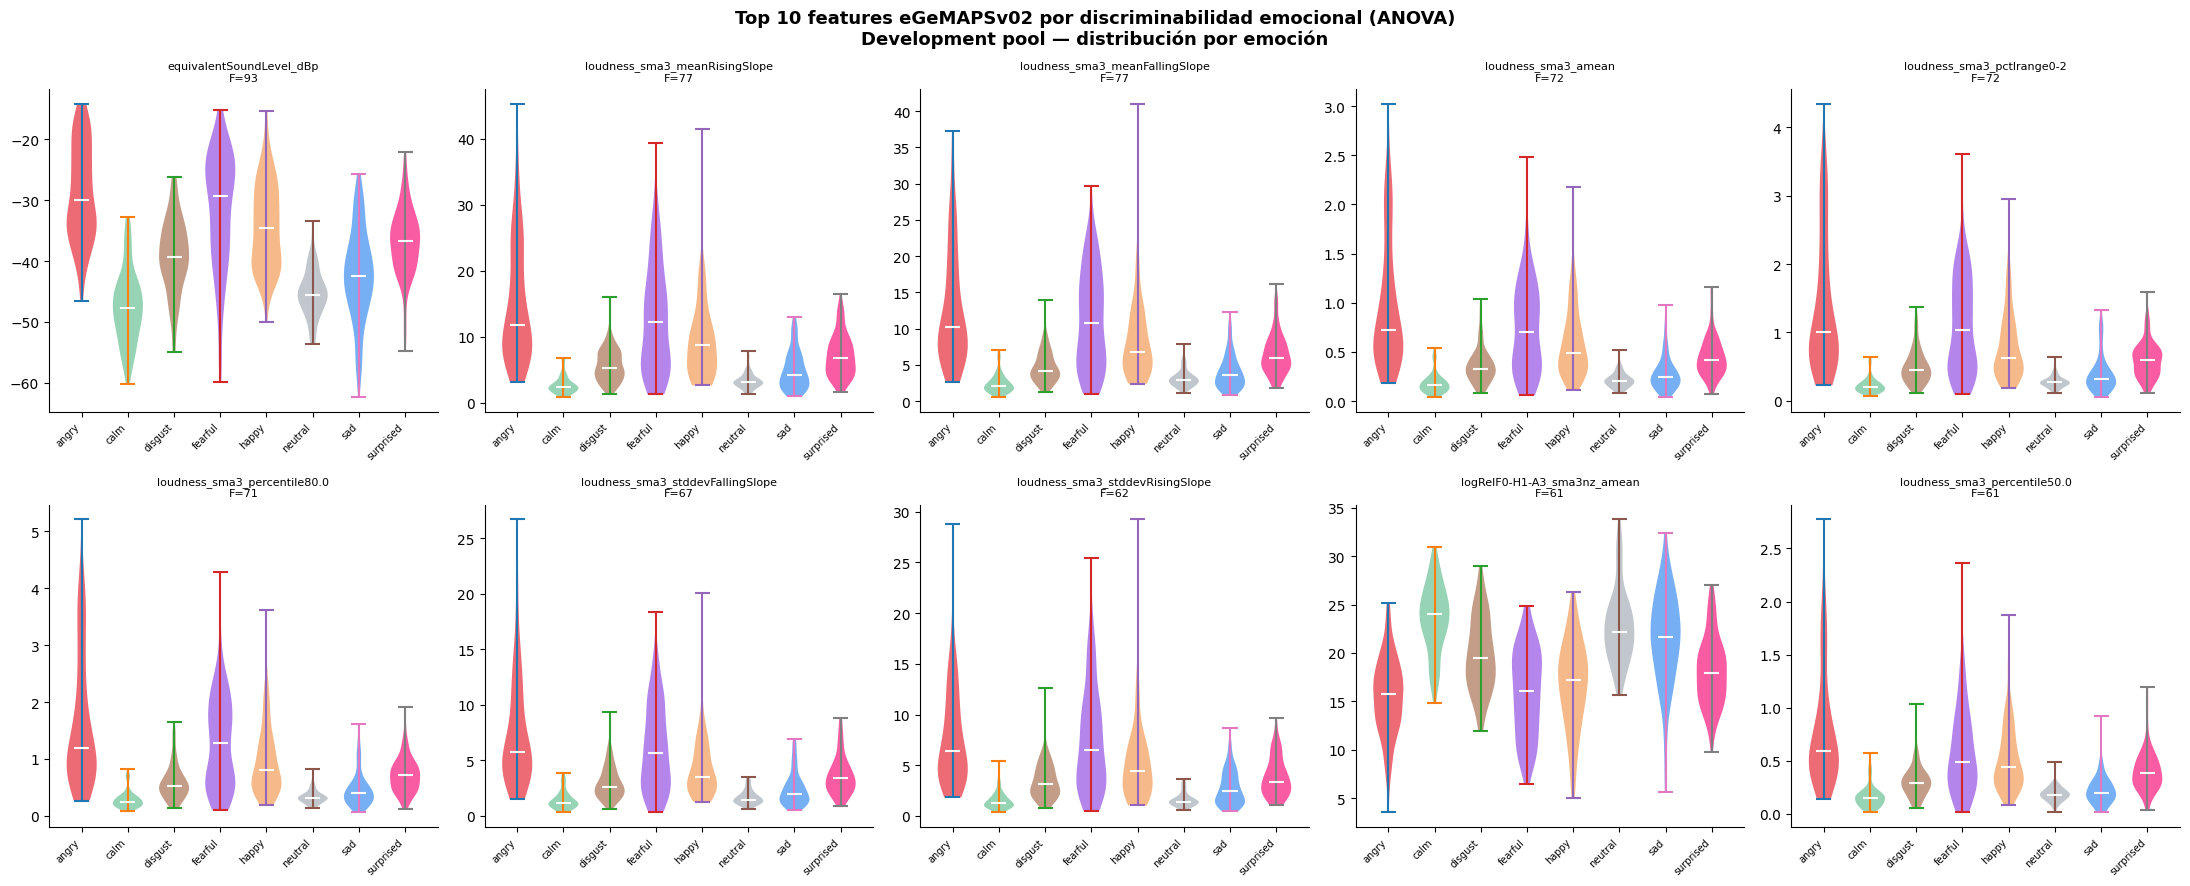

💾 Figura guardada: reports/figures/anova_top10_egemaps.png


In [ ]:
# Visualización: Top 10 features — violin plots por emoción
from sklearn.preprocessing import StandardScaler

top10 = anova_df.head(10)["feature"].tolist()
EMOTION_PALETTE = {
    "neutral":"#ADB5BD", "calm":"#74C69D", "happy":"#F4A261", "sad":"#4895EF",
    "angry":"#E63946",  "fearful":"#9B5DE5", "disgust":"#B07D62", "surprised":"#F72585",
}

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle(
    "Top 10 features eGeMAPSv02 por discriminabilidad emocional (ANOVA)\n"
    "Development pool — distribución por emoción",
    fontsize=13, fontweight="bold"
)

for ax, feat in zip(axes.flatten(), top10):
    f_val = anova_df.loc[anova_df["feature"] == feat, "F"].values[0]
    for j, emo in enumerate(emotions):
        data = egem_merged.loc[egem_merged["emotion_original"] == emo, feat].values
        parts = ax.violinplot(data, positions=[j], showmedians=True, widths=0.65)
        color = EMOTION_PALETTE.get(emo, "steelblue")
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.75)
        parts["cmedians"].set_color("white")
        parts["cmedians"].set_linewidth(1.5)

    ax.set_title(f"{feat[:32]}\nF={f_val:.0f}", fontsize=8)
    ax.set_xticks(range(len(emotions)))
    ax.set_xticklabels(emotions, rotation=45, ha="right", fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "anova_top10_egemaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figura guardada: reports/figures/anova_top10_egemaps.png")

---
## 6 · PCA — Varianza explicada

El PCA sirve para dos propósitos:
1. **Diagnóstico:** ¿cuánta redundancia tienen las representaciones?
2. **Decisión de Sprint 3:** ¿conviene reducir dimensionalidad de wav2vec antes de entrenar?

> El scaler y el PCA **se ajustan sobre el development pool completo** a efectos de visualización. En Sprint 3, se ajustarán **solo en el train de cada fold** para respetar el contrato anti-leakage.

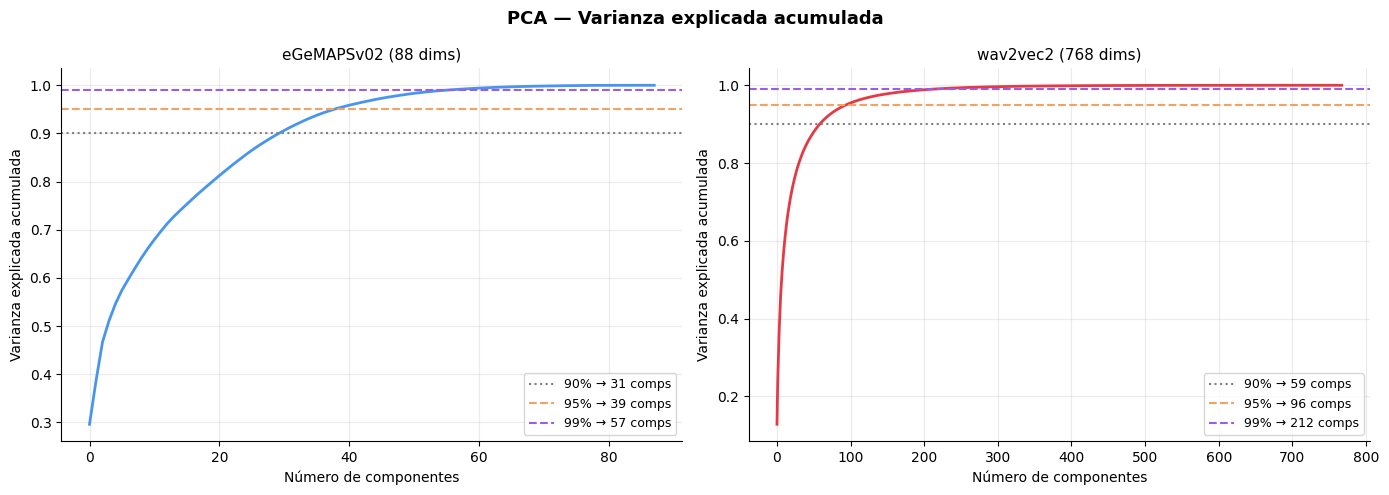

── RESUMEN PCA ──────────────────────────────────────────────
  Representación                   Total    90%    95%    99%
  ──────────────────────────────────────────────────────────
  eGeMAPSv02 (88 dims)                88     31     39     57
  wav2vec2 (768 dims)                768     59     96    212

  → wav2vec tiene alta redundancia: la mayoría de la varianza
    se concentra en pocos componentes. PCA es candidato en Sprint 3.
💾 Figura guardada: reports/figures/pca_variance_explained.png


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA — Varianza explicada acumulada", fontsize=13, fontweight="bold")

pca_results = {}

for ax, X, name, color in [
    (axes[0], X_egem,  "eGeMAPSv02 (88 dims)",   "#4895EF"),
    (axes[1], X_wav2v, "wav2vec2 (768 dims)",     "#E63946"),
]:
    X_sc  = StandardScaler().fit_transform(X)
    pca   = PCA(random_state=cfg.seed)
    pca.fit(X_sc)
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    n90 = int(np.searchsorted(cumvar, 0.90)) + 1
    n95 = int(np.searchsorted(cumvar, 0.95)) + 1
    n99 = int(np.searchsorted(cumvar, 0.99)) + 1
    pca_results[name] = {"n90": n90, "n95": n95, "n99": n99, "total": X.shape[1]}

    ax.plot(cumvar, color=color, linewidth=2)
    ax.axhline(0.90, color="gray",   linestyle=":",  label=f"90% → {n90} comps")
    ax.axhline(0.95, color="#F4A261",linestyle="--", label=f"95% → {n95} comps")
    ax.axhline(0.99, color="#9B5DE5",linestyle="--", label=f"99% → {n99} comps")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Número de componentes")
    ax.set_ylabel("Varianza explicada acumulada")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_variance_explained.png", dpi=150, bbox_inches="tight")
plt.show()

print("── RESUMEN PCA ──────────────────────────────────────────────")
print(f"  {'Representación':<30}  {'Total':>6}  {'90%':>5}  {'95%':>5}  {'99%':>5}")
print("  " + "─" * 58)
for name, r in pca_results.items():
    print(f"  {name:<30}  {r['total']:>6}  {r['n90']:>5}  {r['n95']:>5}  {r['n99']:>5}")
print()
print("  → wav2vec tiene alta redundancia: la mayoría de la varianza")
print("    se concentra en pocos componentes. PCA es candidato en Sprint 3.")
print("💾 Figura guardada: reports/figures/pca_variance_explained.png")

---
## 7 · t-SNE — Estructura geométrica

Reducción no lineal a 2D para explorar visualmente si la geometría del espacio de features está dominada por:
- **Emoción** (deseable: clusters bien separados)
- **Sexo / Identidad del hablante** (indeseable: dominancia de identidad sobre emoción)

Se comparan ambas representaciones en las mismas condiciones (StandardScaler + t-SNE).

In [ ]:
from sklearn.manifold import TSNE

def run_tsne(X: np.ndarray, seed: int, perplexity: int = 30) -> np.ndarray:
    X_sc = StandardScaler().fit_transform(X)
    return TSNE(
        n_components=2, random_state=seed,
        perplexity=perplexity, verbose=0
    ).fit_transform(X_sc)

print("Calculando t-SNE (puede tardar ~1-2 min)...")
emb_egem  = run_tsne(X_egem,  cfg.seed)
emb_wav2v = run_tsne(X_wav2v, cfg.seed)
print("✅ t-SNE completado")

Calculando t-SNE (puede tardar ~1-2 min)...
✅ t-SNE completado


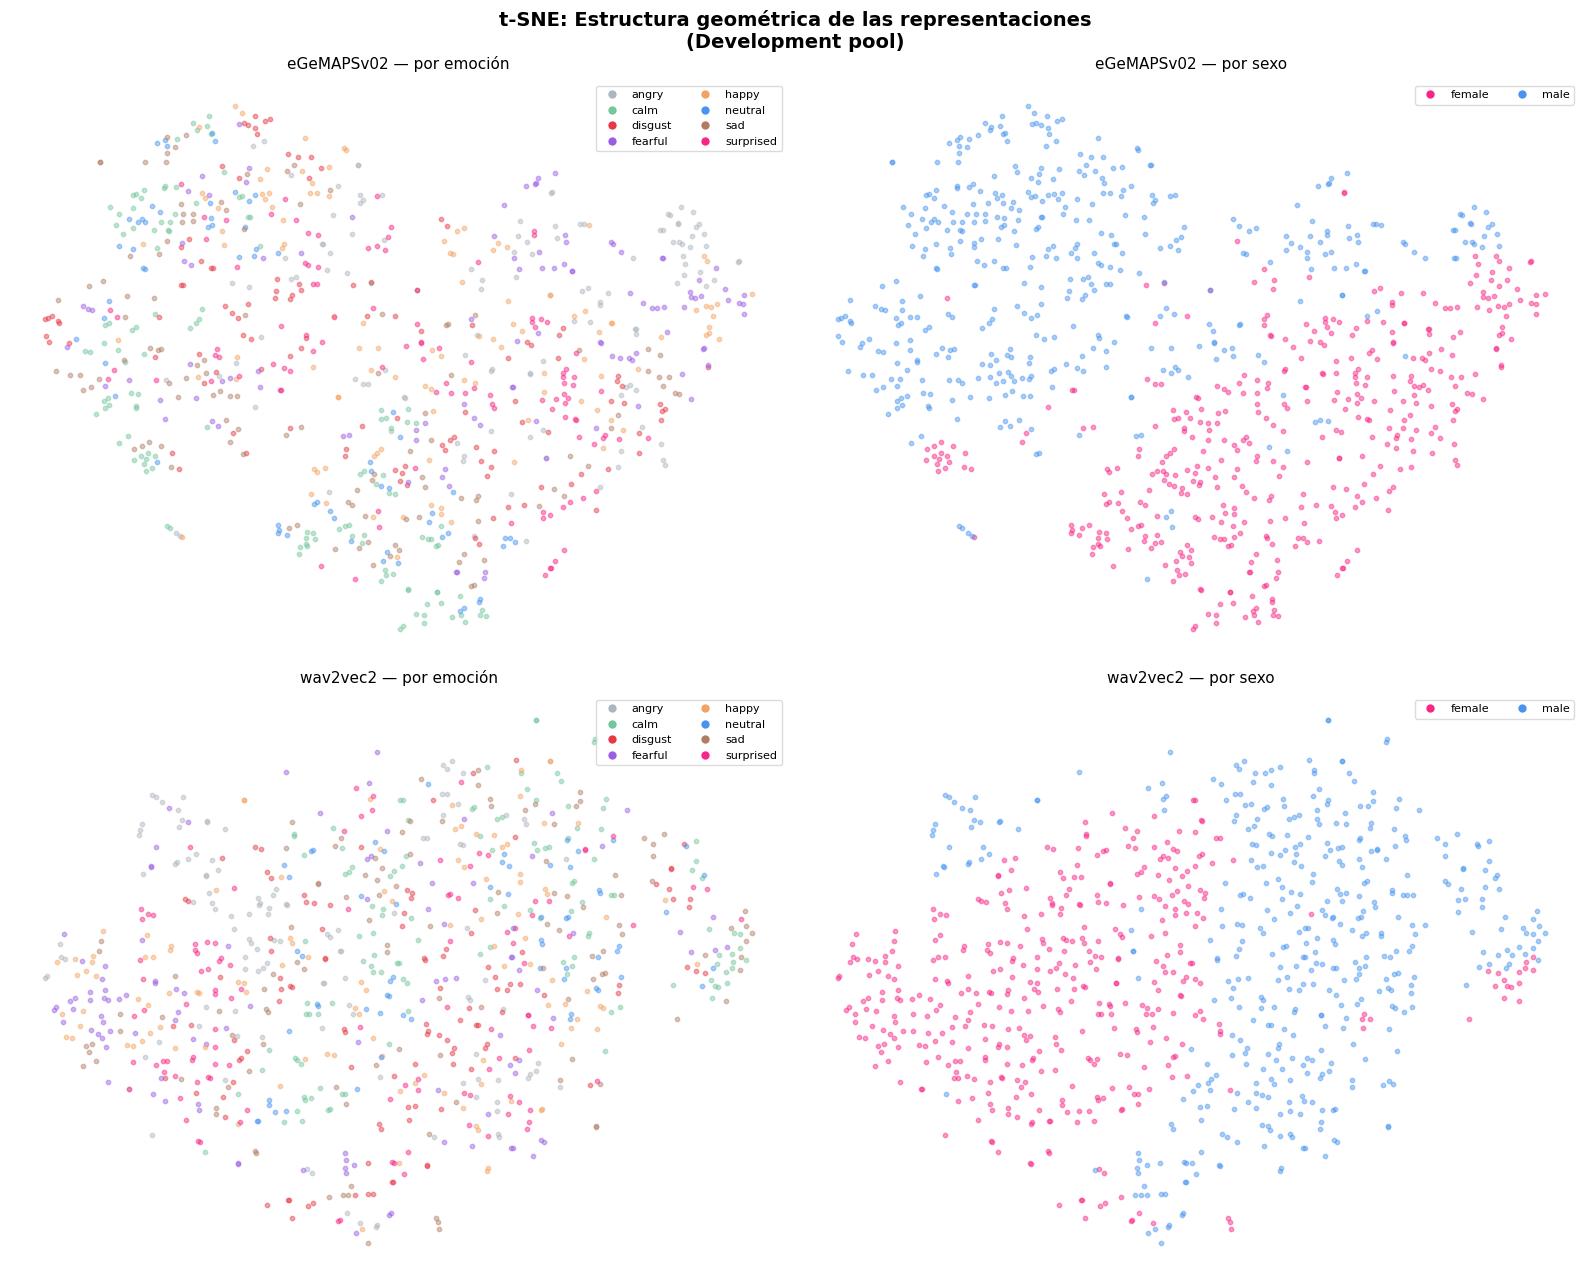

💾 Figura guardada: reports/figures/tsne_repr_comparison.png


In [ ]:
from matplotlib.lines import Line2D

EMOTION_PALETTE_LIST = [
    "#ADB5BD","#74C69D","#E63946","#9B5DE5",
    "#F4A261","#4895EF","#B07D62","#F72585",
]
SEX_PALETTE = {"female": "#F72585", "male": "#4895EF"}

emotions_sorted = sorted(np.unique(y_emo))
emo_palette = dict(zip(emotions_sorted, EMOTION_PALETTE_LIST))

def scatter_labeled(ax, emb, labels, palette_dict, title, alpha=0.45, s=10):
    for label, color in palette_dict.items():
        mask = np.array(labels) == label
        ax.scatter(emb[mask, 0], emb[mask, 1], c=color, alpha=alpha, s=s, label=label)
    ax.set_title(title, fontsize=11, pad=8)
    ax.axis("off")
    ax.legend(
        handles=[
            Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=7, label=l)
            for l, c in palette_dict.items()
        ],
        fontsize=8, loc="best", ncol=2, framealpha=0.7
    )

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle(
    "t-SNE: Estructura geométrica de las representaciones\n(Development pool)",
    fontsize=14, fontweight="bold"
)

scatter_labeled(axes[0,0], emb_egem,  y_emo, emo_palette, "eGeMAPSv02 — por emoción")
scatter_labeled(axes[0,1], emb_egem,  y_sex, SEX_PALETTE, "eGeMAPSv02 — por sexo")
scatter_labeled(axes[1,0], emb_wav2v, y_emo, emo_palette, "wav2vec2 — por emoción")
scatter_labeled(axes[1,1], emb_wav2v, y_sex, SEX_PALETTE, "wav2vec2 — por sexo")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "tsne_repr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figura guardada: reports/figures/tsne_repr_comparison.png")

---
## 8 · Heatmap de correlación — eGeMAPSv02

Se visualiza la correlación entre las **Top 20 features más discriminativas** (por ANOVA).
Grupos de alta correlación sugieren redundancia y validan la utilidad de reducción de dimensionalidad.

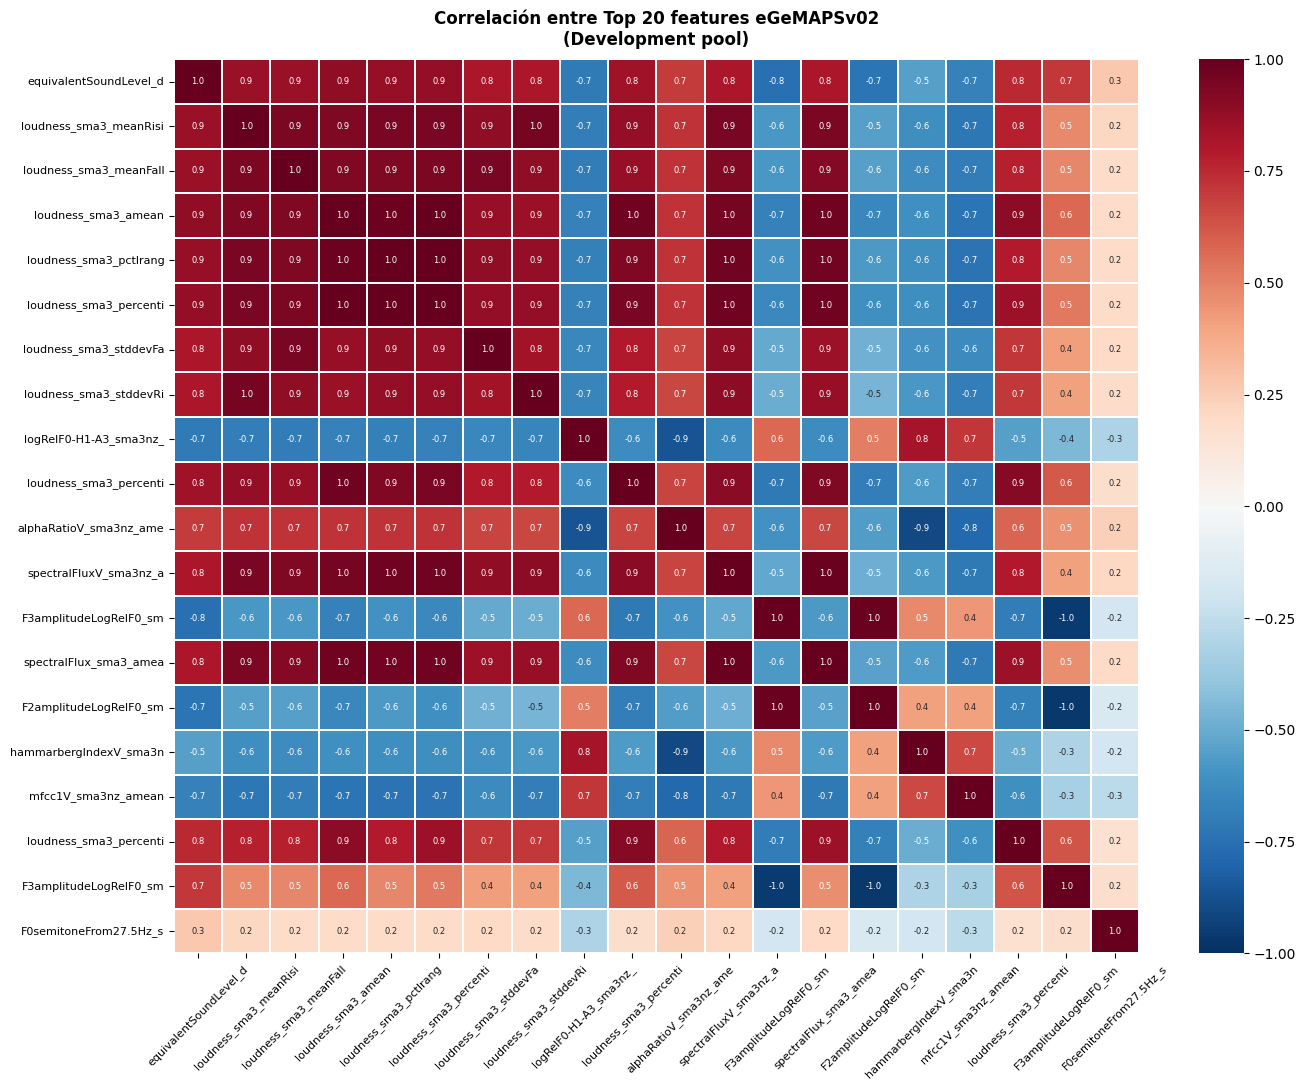

💾 Figura guardada: reports/figures/egemaps_correlation_heatmap.png


In [ ]:
top20 = anova_df.head(20)["feature"].tolist()
corr  = dev_egem[top20].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr,
    annot=True, fmt=".1f", annot_kws={"size": 6},
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor="white",
    xticklabels=[f[:22] for f in top20],
    yticklabels=[f[:22] for f in top20],
    ax=ax,
)
ax.set_title(
    "Correlación entre Top 20 features eGeMAPSv02\n(Development pool)",
    fontsize=12, fontweight="bold", pad=10
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "egemaps_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figura guardada: reports/figures/egemaps_correlation_heatmap.png")

---
## 9 · Conclusiones del Sprint 2

### ✅ Representaciones validadas

| Representación | Cobertura | NaN | Inf | Constantes |
|---|---|---|---|---|
| eGeMAPSv02 | 1440/1440 | 0 | 0 | 0 |
| wav2vec2 | 1440/1440 | 0 | 0 | 0 |

### 📊 Hallazgos del EDA

**ANOVA — eGeMAPSv02:**
- Las features más discriminativas pertenecen al grupo de **loudness, F0 y calidad vocal** — alineado con la literatura SER.
- La gran mayoría de features tienen p < 0.001, lo que indica que la representación es discriminativa.

**PCA:**
- eGeMAPSv02 (88 dims) requiere relativamente pocos componentes para el 95% de varianza → baja redundancia relativa.
- wav2vec2 (768 dims) concentra la varianza en muchos menos componentes → alta redundancia; PCA dentro de CV es recomendable.

**t-SNE:**
- *(Completar con observación real al ejecutar)*: si wav2vec muestra clusters de sexo más marcados que de emoción, confirma que el encoder no supervisado captura identidad del hablante.

### 🎯 Decisiones para Sprint 3

| Decisión | Justificación |
|---|---|
| eGeMAPSv02 → RF + MLP sin reducción | 88 dims manejables; RFECV explorará selección dentro de CV |
| wav2vec → PCA dentro de CV | Alta redundancia; PCA reduce sin perder varianza; se ajusta en train |
| Baseline RF con ambas representaciones | Requerido por el enunciado |
| `class_weight='balanced'` desde el inicio | Desbalance Q2 vs Q3 confirmado en Sprint 1 |

---

> **Sprint 3 puede iniciarse.** Punto de entrada: `notebooks/03_baselines_refinement.ipynb`

In [ ]:
from src.utils.io import save_markdown
import datetime

top3_feats = ", ".join(anova_df.head(3)["feature"].tolist())

report_md = f"""# Sprint 2 — Feature Extraction & EDA Report

**Fecha:** {datetime.date.today()}  
**Seed:** {cfg.seed}

---

## Representaciones extraídas

| Representación | Dims | Archivos | Cache |
|---|---|---|---|
| eGeMAPSv02 Functionals | 88 | {len(egemaps)} | `data/processed/features/egemaps.parquet` |
| wav2vec2-base (mean pooling) | 768 | {len(wav2vec)} | `data/processed/features/wav2vec.parquet` |

## EDA — Hallazgos (development pool, n={len(dev_meta)})

### Top 3 features eGeMAPSv02 (ANOVA)
{top3_feats}

### PCA
- eGeMAPSv02: {pca_results['eGeMAPSv02 (88 dims)']['n95']} componentes para 95% varianza ({pca_results['eGeMAPSv02 (88 dims)']['n95']}/{pca_results['eGeMAPSv02 (88 dims)']['total']})
- wav2vec2:   {pca_results['wav2vec2 (768 dims)']['n95']} componentes para 95% varianza ({pca_results['wav2vec2 (768 dims)']['n95']}/{pca_results['wav2vec2 (768 dims)']['total']})

## Decisiones para Sprint 3

- eGeMAPS se usa directamente (88 dims, manejable).
- wav2vec se explorará con PCA reducción dentro de CV.
- El contrato anti-leakage se mantiene: scaler y PCA se ajustan solo en train de cada fold.
"""

save_markdown(report_md, REPORTS_DIR / "feature_extraction.md")
print("💾 feature_extraction.md guardado en reports/")

💾 feature_extraction.md guardado en reports/
